In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"

In [2]:
df = pd.read_excel("cleaned_dataset.xlsx")

In [3]:
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     object        
 2   gender              60 non-null     object        
 3   age                 60 non-null     int64         
 4   city                60 non-null     object        
 5   province            60 non-null     object        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     object        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     object        
 13  device              60 non-null     object        
 

In [5]:
df.shape

(60, 17)

In [6]:
df.isnull().sum()

customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [8]:
df["calculated_spending"] = (
    df["purchase_count"] *
    df["avg_order_value"]
)

df["spending_difference"] = (
    df["total_spending"] -
    df["calculated_spending"]
)

print(
    "Rows with spending mismatch:",
    (df["spending_difference"].abs() > 0.01).sum()
)

Rows with spending mismatch: 0


In [9]:
df[[
    "customer_id",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "calculated_spending",
    "spending_difference"
]].head()

,customer_id,purchase_count,avg_order_value,total_spending,calculated_spending,spending_difference
0,1001,17,121.53,2066.01,2066.01,0.000000e+00
1,1002,12,326.47,3917.64,3917.64,-4.547474e-13
2,1003,21,59.46,1248.66,1248.66,0.000000e+00
3,1004,23,266.15,6121.45,6121.45,0.000000e+00
4,1005,23,169.54,3899.42,3899.42,4.547474e-13


In [10]:
total_customers = df['customer_id'].nunique()
total_purchases = df['purchase_count'].sum()
total_revenue = df['total_spending'].sum()
average_customer_spending = df['total_spending'].mean()
average_order_value = df['avg_order_value'].mean()
average_satisfaction = df['satisfaction_score'].mean()
average_returned_items = df["returned_items"].mean()

In [11]:
print("Total Customers:", total_customers)
print("Total Purchases:", total_purchases)
print("Total Revenue:", total_revenue)
print("Average Customer Spending:", round(average_customer_spending, 2))
print("Average Order Value:", round(average_order_value, 2))
print("Average Satisfaction:", round(average_satisfaction, 2))
print("Average Returned Items:", round(average_returned_items, 2))

Total Customers: 60
Total Purchases: 1043
Total Revenue: 201985.72999999998
Average Customer Spending: 3366.43
Average Order Value: 213.16
Average Satisfaction: 2.98
Average Returned Items: 4.18


In [12]:
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Purchases",
        "Total Revenue",
        "Average Customer Spending",
        "Average Order Value",
        "Average Satisfaction",
        "Average Returned Items"
    ],
    "Value": [
        total_customers,
        total_purchases,
        total_revenue,
        average_customer_spending,
        average_order_value,
        average_satisfaction,
        average_returned_items
    ]
})

summary["Value"] = summary["Value"].round(2)

summary

,Metric,Value
0,Total Customers,60.00
1,Total Purchases,1043.00
2,Total Revenue,201985.73
3,Average Customer Spending,3366.43
4,Average Order Value,213.16
5,Average Satisfaction,2.98
6,Average Returned Items,4.18


In [13]:
city_analysis = df.groupby("city").agg(
    customers=("customer_id", "nunique"),
    purchases=("purchase_count", "sum"),
    revenue=("total_spending", "sum"),
    average_spending=("total_spending", "mean"),
    satisfaction=("satisfaction_score", "mean"),
    returned_items=("returned_items", "sum")
).reset_index()

city_analysis

,city,customers,purchases,revenue,average_spending,satisfaction,returned_items
0,Ahvaz,8,111,23384.78,2923.097500,3.500000,39
1,Isfahan,5,99,21975.32,4395.064000,4.400000,22
2,Karaj,7,112,26189.81,3741.401429,2.857143,34
3,Mashhad,11,249,43197.58,3927.052727,2.909091,29
4,Rasht,5,82,15168.54,3033.708000,2.600000,22
5,Shiraz,6,98,20715.92,3452.653333,2.000000,29
6,Tabriz,12,189,36192.49,3016.040833,3.000000,55
7,Tehran,6,103,15161.29,2526.881667,2.666667,21


In [14]:
city_analysis = city_analysis.sort_values(
    by="revenue",
    ascending=False
)

city_analysis

,city,customers,purchases,revenue,average_spending,satisfaction,returned_items
3,Mashhad,11,249,43197.58,3927.052727,2.909091,29
6,Tabriz,12,189,36192.49,3016.040833,3.000000,55
2,Karaj,7,112,26189.81,3741.401429,2.857143,34
0,Ahvaz,8,111,23384.78,2923.097500,3.500000,39
1,Isfahan,5,99,21975.32,4395.064000,4.400000,22
5,Shiraz,6,98,20715.92,3452.653333,2.000000,29
4,Rasht,5,82,15168.54,3033.708000,2.600000,22
7,Tehran,6,103,15161.29,2526.881667,2.666667,21


In [15]:
city_analysis[[
    "revenue",
    "average_spending",
    "satisfaction",
    "returned_items"
]] = city_analysis[[
    "revenue",
    "average_spending",
    "satisfaction",
    "returned_items"
]].round(2)

city_analysis

,city,customers,purchases,revenue,average_spending,satisfaction,returned_items
3,Mashhad,11,249,43197.58,3927.05,2.91,29
6,Tabriz,12,189,36192.49,3016.04,3.00,55
2,Karaj,7,112,26189.81,3741.40,2.86,34
0,Ahvaz,8,111,23384.78,2923.10,3.50,39
1,Isfahan,5,99,21975.32,4395.06,4.40,22
5,Shiraz,6,98,20715.92,3452.65,2.00,29
4,Rasht,5,82,15168.54,3033.71,2.60,22
7,Tehran,6,103,15161.29,2526.88,2.67,21


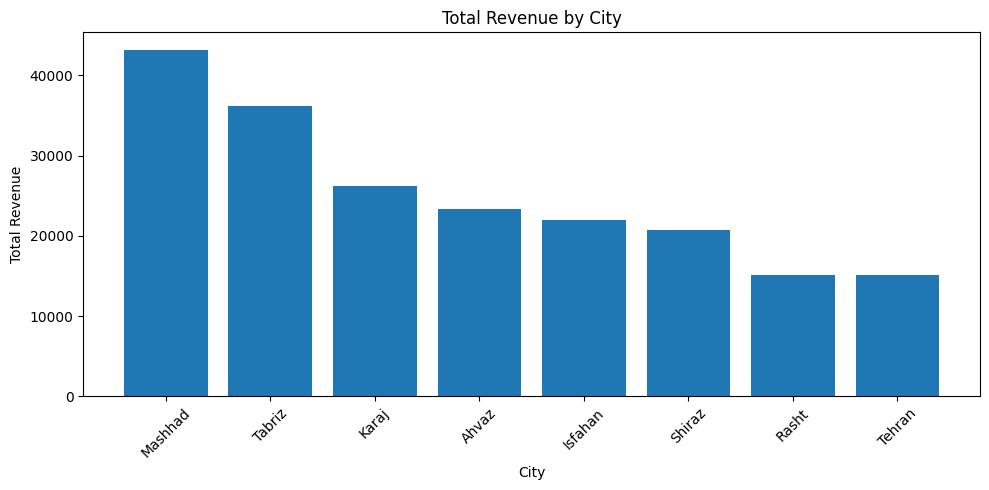

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(
    city_analysis["city"],
    city_analysis["revenue"]
)

plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
loyalty_customers = df[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
].copy()

In [18]:
loyalty_customers["spending_score"] = (
    loyalty_customers["total_spending"] /
    loyalty_customers["total_spending"].max()
)

loyalty_customers["purchase_score"] = (
    loyalty_customers["purchase_count"] /
    loyalty_customers["purchase_count"].max()
)

loyalty_customers["satisfaction_score_normalized"] = (
    loyalty_customers["satisfaction_score"] /
    loyalty_customers["satisfaction_score"].max()
)

loyalty_customers["recency_score"] = (
    1 -
    loyalty_customers["last_purchase_days"] /
    loyalty_customers["last_purchase_days"].max()
)

In [19]:
loyalty_customers["loyalty_score"] = (
    loyalty_customers["spending_score"] * 0.40 +
    loyalty_customers["purchase_score"] * 0.30 +
    loyalty_customers["satisfaction_score_normalized"] * 0.20 +
    loyalty_customers["recency_score"] * 0.10
)

In [20]:
top_10_loyalty = loyalty_customers.sort_values(
    "loyalty_score",
    ascending=False
).head(10)

In [21]:
top_10_loyalty = top_10_loyalty[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
]

top_10_loyalty

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
56,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4
43,1044,Mina,Shiraz,Gold,33,14354.34,165,2
58,1059,Ali,Isfahan,Gold,31,8898.55,224,5
8,1009,Kimia,Karaj,Silver,34,11615.42,232,2
11,1012,Arash,Mashhad,Gold,27,11731.50,224,2
32,1033,Neda,Tabriz,VIP,24,5521.20,112,5
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4
22,1023,Ali,Mashhad,Bronze,31,3851.44,170,4
16,1017,Parsa,Ahvaz,VIP,30,3239.40,135,4


In [22]:
spending_median = df["total_spending"].median()

at_risk = df[
    (df["total_spending"] >= spending_median) &
    (df["last_purchase_days"] > 180)
].copy()

In [23]:
print("Number of At-Risk Customers:", len(at_risk))

Number of At-Risk Customers: 18


In [24]:
at_risk = at_risk[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
].sort_values(
    "total_spending",
    ascending=False
)

at_risk

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
11,1012,Arash,Mashhad,Gold,27,11731.50,224,2
8,1009,Kimia,Karaj,Silver,34,11615.42,232,2
58,1059,Ali,Isfahan,Gold,31,8898.55,224,5
9,1010,Arash,Karaj,Silver,19,7241.47,276,1
49,1050,Reza,Mashhad,Bronze,30,6198.00,205,2
54,1055,Mina,Rasht,Bronze,19,6068.22,221,1
34,1035,Arash,Tabriz,Bronze,17,5918.21,365,3
52,1053,Sina,Tehran,Gold,18,5805.54,320,1
45,1046,Maryam,Tabriz,VIP,15,4923.45,229,4
31,1032,Neda,Isfahan,Silver,15,4615.05,243,5


In [25]:
df["discount_used"].value_counts()

discount_used
No     34
Yes    26
Name: count, dtype: int64

In [26]:
discount_analysis = df.groupby("discount_used").agg(
    customers=("customer_id", "nunique"),
    average_spending=("total_spending", "mean"),
    average_purchases=("purchase_count", "mean"),
    average_satisfaction=("satisfaction_score", "mean"),
    average_returned_items=("returned_items", "mean")
).reset_index()

discount_analysis

,discount_used,customers,average_spending,average_purchases,average_satisfaction,average_returned_items
0,No,34,3736.741176,17.294118,2.764706,4.264706
1,Yes,26,2882.174231,17.500000,3.269231,4.076923


In [27]:
discount_analysis = discount_analysis.round(2)

discount_analysis

,discount_used,customers,average_spending,average_purchases,average_satisfaction,average_returned_items
0,No,34,3736.74,17.29,2.76,4.26
1,Yes,26,2882.17,17.50,3.27,4.08


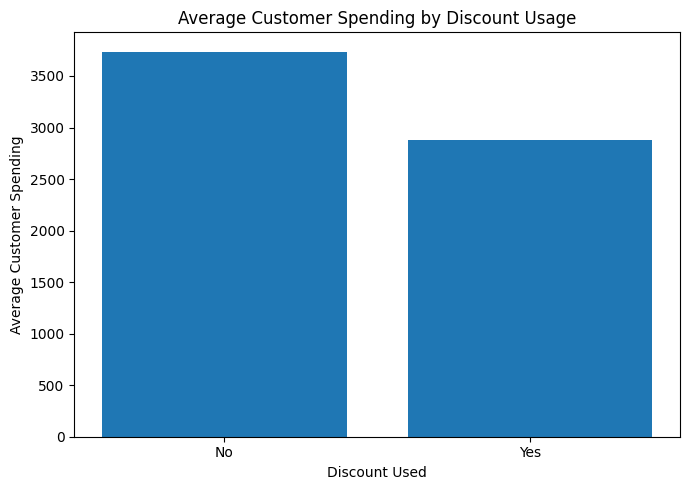

In [28]:
plt.figure(figsize=(7, 5))

plt.bar(
    discount_analysis["discount_used"].astype(str),
    discount_analysis["average_spending"]
)

plt.xlabel("Discount Used")
plt.ylabel("Average Customer Spending")
plt.title("Average Customer Spending by Discount Usage")

plt.tight_layout()
plt.show()

In [29]:
spending_median = df["total_spending"].median()
purchase_median = df["purchase_count"].median()

In [30]:
def segment_customer(row):
    
    if (
        row["total_spending"] >= spending_median
        and row["purchase_count"] >= purchase_median
        and row["last_purchase_days"] <= 90
    ):
        return "Champions"
    
    elif (
        row["total_spending"] >= spending_median
        and row["last_purchase_days"] > 180
    ):
        return "At Risk"
    
    elif (
        row["total_spending"] >= spending_median
        and row["purchase_count"] >= purchase_median
    ):
        return "Loyal Customers"
    
    else:
        return "Needs Attention"

In [31]:
df["customer_segment"] = df.apply(
    segment_customer,
    axis=1
)

In [32]:
df["customer_segment"].value_counts()

customer_segment
Needs Attention    33
At Risk            18
Loyal Customers     7
Champions           2
Name: count, dtype: int64

In [33]:
segment_analysis = df.groupby("customer_segment").agg(
    customers=("customer_id", "nunique"),
    average_spending=("total_spending", "mean"),
    average_purchases=("purchase_count", "mean"),
    average_last_purchase_days=("last_purchase_days", "mean"),
    average_satisfaction=("satisfaction_score", "mean")
).reset_index()

segment_analysis.round(2)

,customer_segment,customers,average_spending,average_purchases,average_last_purchase_days,average_satisfaction
0,At Risk,18,5493.62,22.22,265.72,2.72
1,Champions,2,9827.09,27.00,61.00,4.00
2,Loyal Customers,7,5610.31,28.00,141.57,3.29
3,Needs Attention,33,1338.61,11.91,182.42,3.00


In [34]:
segment_analysis = segment_analysis.round(2)

segment_analysis

,customer_segment,customers,average_spending,average_purchases,average_last_purchase_days,average_satisfaction
0,At Risk,18,5493.62,22.22,265.72,2.72
1,Champions,2,9827.09,27.00,61.00,4.00
2,Loyal Customers,7,5610.31,28.00,141.57,3.29
3,Needs Attention,33,1338.61,11.91,182.42,3.00


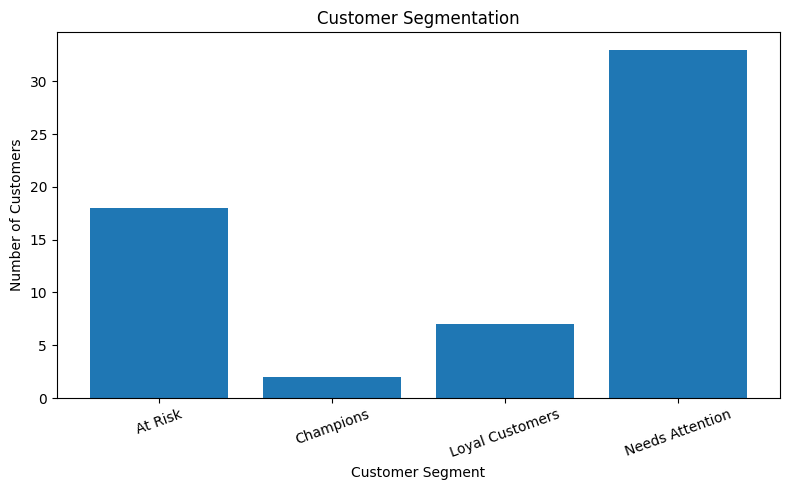

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis["customer_segment"],
    segment_analysis["customers"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segmentation")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [36]:
pareto = df[
    ["customer_id", "total_spending"]
].sort_values(
    "total_spending",
    ascending=False
).copy()

In [37]:
top_20_count = int(np.ceil(len(pareto) * 0.20))

print("Top 20% customer count:", top_20_count)

Top 20% customer count: 12


In [38]:
top_20 = pareto.head(top_20_count)

In [39]:
top_20_revenue = top_20["total_spending"].sum()

total_revenue = df["total_spending"].sum()

top_20_revenue_percentage = (
    top_20_revenue / total_revenue
) * 100

print(
    "Revenue generated by top 20% customers:",
    round(top_20_revenue_percentage, 2),
    "%"
)

Revenue generated by top 20% customers: 51.0 %


In [40]:
pareto["cumulative_revenue"] = (
    pareto["total_spending"].cumsum()
)

pareto["cumulative_revenue_percentage"] = (
    pareto["cumulative_revenue"] /
    total_revenue
) * 100

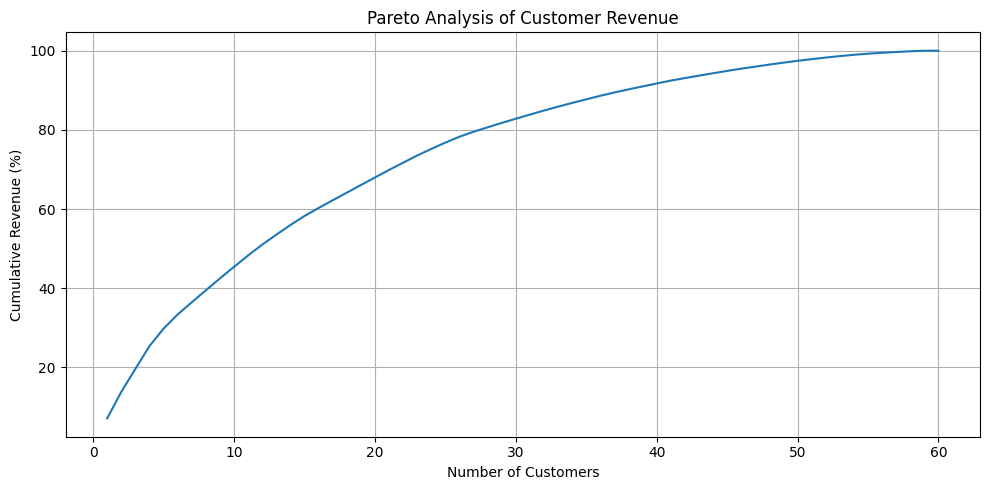

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(pareto) + 1),
    pareto["cumulative_revenue_percentage"]
)

plt.xlabel("Number of Customers")
plt.ylabel("Cumulative Revenue (%)")
plt.title("Pareto Analysis of Customer Revenue")

plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
import os

os.makedirs("charts", exist_ok=True)

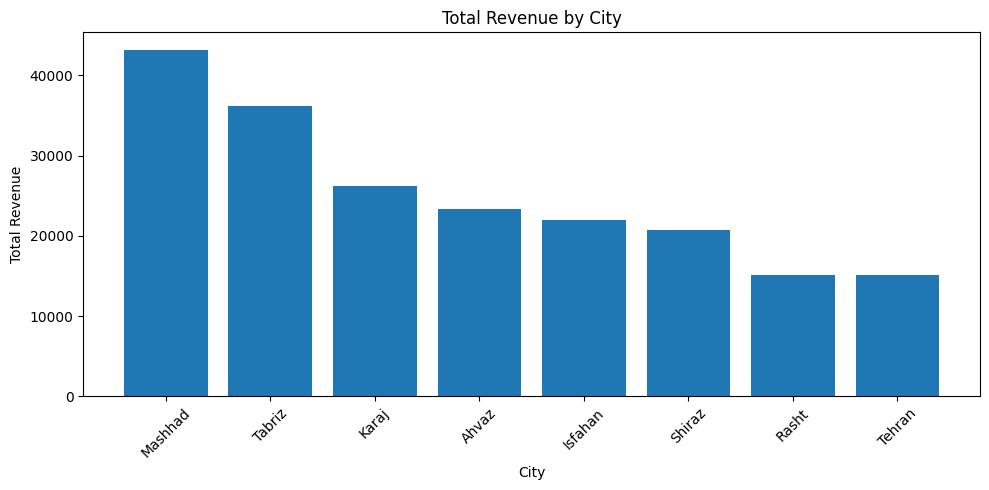

In [43]:
plt.figure(figsize=(10, 5))

plt.bar(
    city_analysis["city"],
    city_analysis["revenue"]
)

plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by City")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "charts/revenue_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

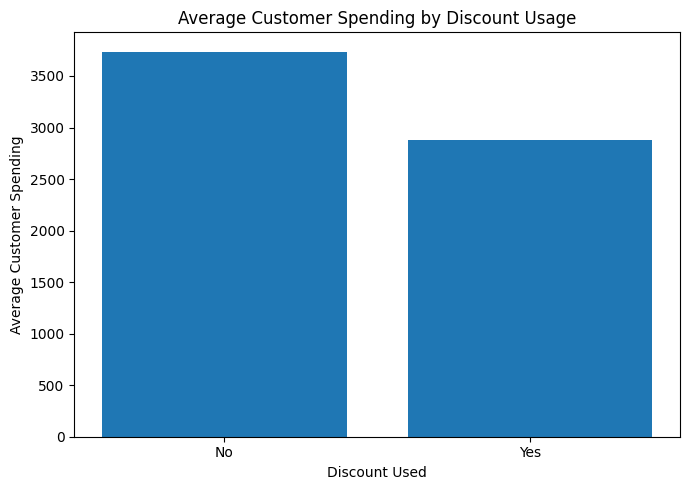

In [44]:
plt.figure(figsize=(7, 5))

plt.bar(
    discount_analysis["discount_used"].astype(str),
    discount_analysis["average_spending"]
)

plt.xlabel("Discount Used")
plt.ylabel("Average Customer Spending")
plt.title("Average Customer Spending by Discount Usage")

plt.tight_layout()

plt.savefig(
    "charts/discount_vs_spending.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

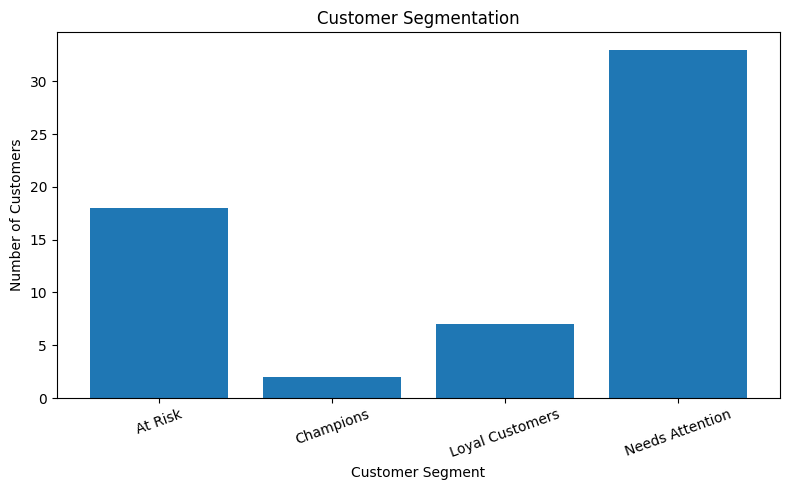

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis["customer_segment"],
    segment_analysis["customers"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segmentation")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "charts/customer_segmentation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Managerial Recommendations

### 1. Focus on High-Value Customers
The top 20% of customers generate approximately 51% of total revenue. Therefore, the company should prioritize retaining high-value customers through personalized loyalty benefits, exclusive offers, and targeted retention campaigns.

### 2. Reactivate At-Risk Customers
18 customers were identified as at-risk because they had relatively high spending but had not made a purchase for more than 180 days. The company should launch targeted reactivation campaigns using personalized offers and reminders to encourage these customers to return.

### 3. Use Discounts More Strategically
Customers who used discounts had higher average satisfaction (3.27 vs. 2.76), but lower average spending (2882.17 vs. 3736.74). Therefore, discounts should be targeted toward specific customer groups and evaluated based on their ability to increase customer value without unnecessarily reducing revenue.

In [46]:
print("Dataset shape:", df.shape)

print("\nNumber of unique customers:",
      df["customer_id"].nunique())

print("\nAge range:")
print(df["age"].min(), "to", df["age"].max())

print("\nMembership distribution:")
print(df["membership_tier"].value_counts())

print("\nGender distribution:")
print(df["gender"].value_counts())

print("\nCity distribution:")
print(df["city"].value_counts())

print("\nSatisfaction distribution:")
print(df["satisfaction_score"].value_counts())

print("\nDiscount usage:")
print(df["discount_used"].value_counts())

Dataset shape: (60, 20)

Number of unique customers: 60

Age range:
19 to 65

Membership distribution:
membership_tier
Gold      19
Bronze    18
VIP       15
Silver     8
Name: count, dtype: int64

Gender distribution:
gender
F    35
M    25
Name: count, dtype: int64

City distribution:
city
Tabriz     12
Mashhad    11
Ahvaz       8
Karaj       7
Tehran      6
Shiraz      6
Isfahan     5
Rasht       5
Name: count, dtype: int64

Satisfaction distribution:
satisfaction_score
2    16
4    13
5    12
1    11
3     8
Name: count, dtype: int64

Discount usage:
discount_used
No     34
Yes    26
Name: count, dtype: int64


## Dataset Limitations

- The dataset contains only 60 customers, so the results may not be representative of a larger customer population.
- The dataset covers a limited number of cities and customer groups.
- The available data is customer-level data and does not contain detailed transaction-level information.
- The analysis is primarily descriptive and does not establish causal relationships.
- Customer segmentation is based on predefined business rules and median thresholds rather than machine learning clustering.

In [47]:
with pd.ExcelWriter("analysis_results.xlsx") as writer:

    summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    city_analysis.to_excel(
        writer,
        sheet_name="City Analysis",
        index=False
    )

    top_10_loyalty.to_excel(
        writer,
        sheet_name="Top 10 Loyalty",
        index=False
    )

    at_risk.to_excel(
        writer,
        sheet_name="At Risk",
        index=False
    )

    discount_analysis.to_excel(
        writer,
        sheet_name="Discount Analysis",
        index=False
    )

    segment_analysis.to_excel(
        writer,
        sheet_name="Segments",
        index=False
    )

    pareto.to_excel(
        writer,
        sheet_name="Pareto",
        index=False
    )